Jessica Salguero, UIN: 937005006
# CSCE 676: Final Data Mining Project
# **Geographic Differences in YouTube Search Results and Misinformation Exposure**

My CSCE 676 Data Mining Project investigates whether YouTube search results differ across geographic locations for the same query, and whether these differences affect exposure to misinformation-related content.

Using a large-scale audit dataset, I analyzed search results across countries, queries, filters, and time. I applied data mining techniques to identify patterns in channel repetition, rates of misinformation, and result consistency.

The goal is to understand whether YouTube search results behave differently based on the user's location, and how this may impact the information users are being exposed to.

---
## Motivation

YouTube is a major source of information for many users, but its search and ranking systems can influence what content is displayed to users. The videos that people see can shape what they believe, especially when it comes to controversial topics. If search results differ across geographic locations, users in different countries may be exposed to different perspectives or levels of misinformation.

Understanding these differences is important because repeated exposure to the same types of content or sources can shape user beliefs. This project aims to explore whether such differences exist and how they may affect misinformation exposure.

---
## Primary Research Question

**Does geographic location influence YouTube search results for the same query, and does this affect exposure to misinformation?**

This question focuses on comparing search results across countries to determine whether users are shown different content for the same query, and whether those differences lead to varying levels of misinformation exposure.

---
## Dataset Description

This project uses a YouTube audit dataset that collects search results across multiple queries, countries, and search filters.

The dataset includes:
- Results from the United States and South Africa  
- Multiple queries related to COVID-19 topics  
- Multiple audit runs per query  
- Channel names and search filter information  
- Annotation labels indicating whether a video supports misinformation  

Annotation labels:
- 1 = supporting misinformation  
- 0 = neutral  
- -1 = opposing misinformation  

---
## Data Preparation

To get the data ready for analysis, I grouped the results by country, query, and run. Each group was treated like a set of channels that appeared together in the search results.

I focused on channels instead of video titles because titles are usually unique, while channels show up more consistently and make it easier to find patterns. Additionally, using channel-level analysis makes it easier to compare results across countries and better understand which sources users are being exposed to.

In [102]:
# From checkpoint 1
# load in libraries I'll need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# load in multiple result files to create dataset
youtube_search_results_path = "/Users/jsalguero/Downloads/search-results"
list_of_search_result_files = os.listdir(youtube_search_results_path) # 12 zip files

# combine result files into one dataset
search_result_dfs = []
for i in list_of_search_result_files:
    # save information from the file names
    # city-bot_num-top50-search-results
    if i.endswith(".csv"): # don't want to do this for any hidden files in the folder
        split_filename = i.split("-")
        #print(i)
        city = split_filename[0]
        bot_num = split_filename[1]
        # 3 cities from USA, 3 cities from South Africa
        if(city == "houston" or city == "losangeles" or city == "jacksonville"):
            country = "USA"
        else:
            country = "South Africa"

        # add the columns to each dataset
        curr_df = pd.read_csv(youtube_search_results_path + "/" + i)
        curr_df["city"] = city
        curr_df["bot_num"] = bot_num
        curr_df["country"] = country

        # to keep all individual dfs and combine them later, add each df into a list
        search_result_dfs.append(curr_df)

# combine into one dataset
youtube_search_result_df = pd.concat(search_result_dfs, ignore_index=True)
#print(youtube_search_result_df)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


/var/folders/04/724khnx95b33tvl0d03w3mgc0017vt/T/ipykernel_46917/3848428116.py:29: DtypeWarning: Columns (0: Channel URL) have mixed types. Specify dtype option on import or set low_memory=False.
  curr_df = pd.read_csv(youtube_search_results_path + "/" + i)


---
## Exploratory Data Analysis (EDA):
I started with exploratory data analysis (EDA) to understand the structure of the dataset and identify some initial patterns. This step helped me see how misinformation varies across countries, filters, and audit runs. 

## EDA 1: Misinformation by Country

First, I looked at how much misinformation appears in search results for each country. This helps directly answer whether users in different locations are exposed to different levels of misinformation.

Using the combined dataset, I counted the number of videos directly labeled as "supporting misinformation" (annotation = 1). Then, I compared the percentages across countries to see if there were noticeable differences in the search results.

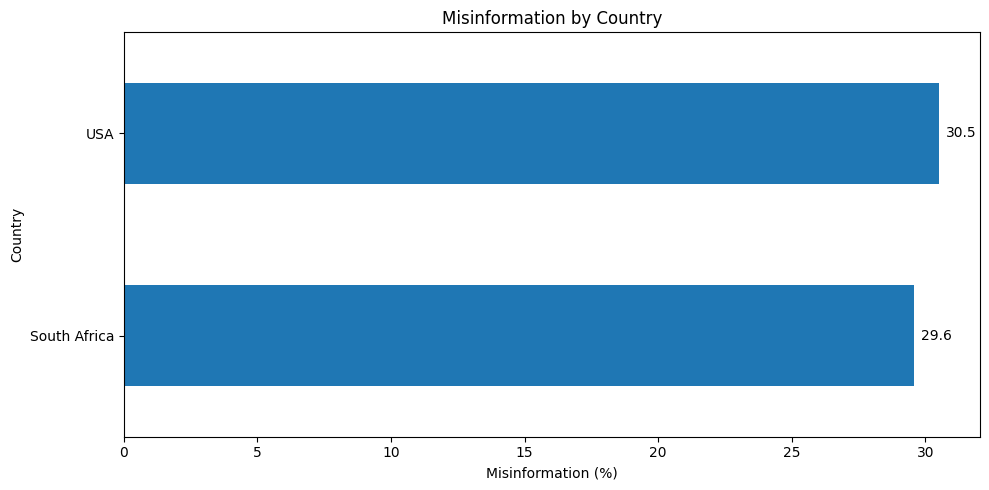

In [103]:
# from checkpoint 1
# which country has more misinformation in search queries?
# annotation: 1 = supporting misinformation, 0 = neutral, -1 = opposing misinformation
misinformation = youtube_search_result_df[youtube_search_result_df["annotation"] == 1]

# count by country
misinformation_country_counts = misinformation["country"].value_counts()
#print(misinformation_country_counts)

# both countries don't have same number of videos
video_counts_country = youtube_search_result_df["country"].value_counts()
#print(video_counts_country) # US has more videos in the combined dataset than South Africa

# final misinformation counts
final_misinformation = (misinformation_country_counts/video_counts_country)*100
#print("Percent of Videos Leading Towards Misinformation Per Country:")
#print(final_misinformation)

# barchart to visualize the results'
# visualize with barchart
plt.figure(figsize=(10, 5))
final_misinformation.sort_values().plot(kind="barh")
plt.xlabel("Misinformation (%)")
plt.ylabel("Country")
plt.title("Misinformation by Country")
plt.tight_layout()
# add values to bars
for i, v in enumerate(final_misinformation.sort_values().values):
    plt.text(v + 0.25, i, round(v, 1), va='center')
plt.show()

The resulting figure from EDA 1 shows that misinformation levels do differ between countries, since the USA had a higher percentage of videos labeled as "supporting misinformation" than South Africa. This suggests that location does have an effect on what users see in search results. Two users searching for the same query in different countries may be exposed to different levels of reliable information. Even small differences can add up, especially since these results are repeated across multiple search queries and audit runs.

Overall, this supports the idea that geographic location plays a role in shaping how much misinformation users are exposed to on YouTube.

## EDA 2: Misinformation by Search Filter

Second, I looked at how different search filters affect misinformation exposure. This is important because YouTube users can sort search results by view count, upload date, rating, or relevance. 

Different search filters will change the order of videos shown for the same query. Since this dataset captures the top 50 results, the ordering of videos matters a lot. Changing the filter could bring different types of content to the top, which may include more or less misinformation. The results from this EDA can provide evidence for whether these filtering choices impact how much misinformation users are exposed to.

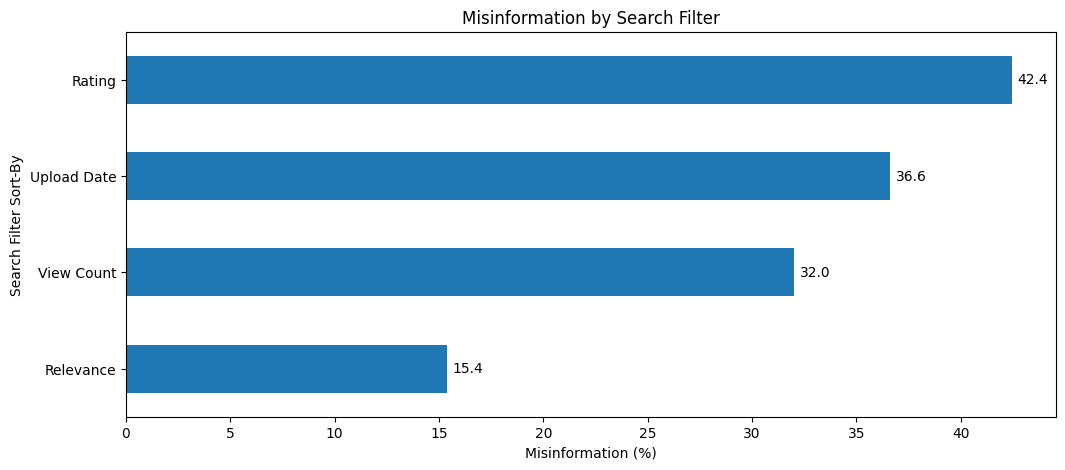

In [104]:
# EDA --> misinformation based on search filter
# annotation: 1 = supporting misinformation, 0 = neutral, -1 = opposing misinformation

# count by filter
misinformation_filter_counts = misinformation["Search Filter Sort-By"].value_counts()
video_counts_filter = youtube_search_result_df["Search Filter Sort-By"].value_counts()

# final misinformation counts
filter_misinformation = ((misinformation_filter_counts/video_counts_filter)*100).fillna(0)
filter_misinformation = filter_misinformation.sort_values(ascending=False)
#print("Percent of Videos Leading Towards Misinformation Per Search Filter:")
#print(filter_misinformation)

# barchart
plt.figure(figsize=(12, 5))
filter_misinformation.sort_values().plot(kind="barh")
plt.title("Misinformation by Search Filter")
plt.xlabel("Misinformation (%)")
plt.ylabel("Search Filter Sort-By")
# add values to bars
for i, v in enumerate(filter_misinformation.sort_values().values):
    plt.text(v + 0.25, i, round(v, 1), va='center')
plt.show()

The results from EDA 2 show that misinformation levels do differ across search filters. Some filters result in a higher percentage of videos labeled as “supporting misinformation” compared to others. Specifically, "Rating" has the highest percentage of videos supporting misinformation.

This suggests that the way search results are sorted can influence the type of content that users are shown. Since users are more likely to click on higher-ranked videos, certain filters can affect how much misinformation users are being exposed to.

## EDA 3: Top 10 Channels by Country

Next, I looked at the top 10 most frequent channels for each country. This channel-level EDA helps show which sources appear the most often within search results and whether users in different countries are being exposed to the same channels or different ones.

Repeated exposure to certain channels is important because it can help explain differences in misinformation rates. If users in different countries are seeing different channels more often, then those channels could be contributing to differences in how much “supporting misinformation” content appears in their query results.

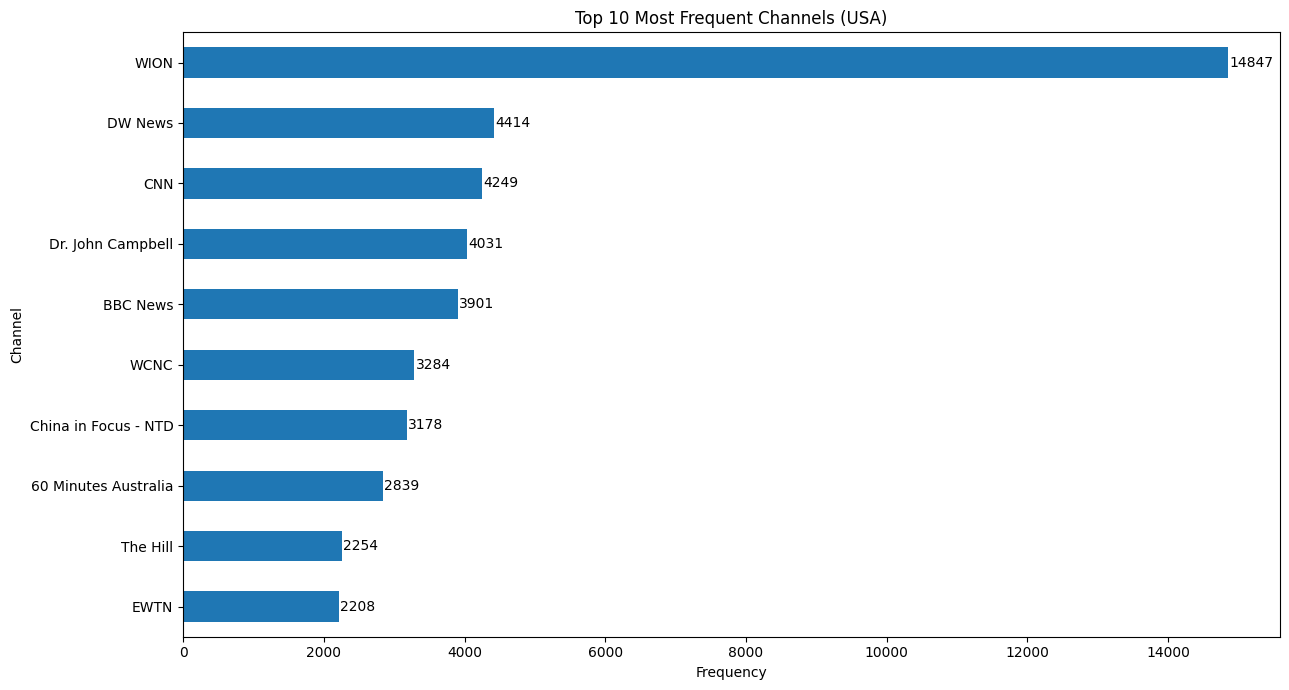

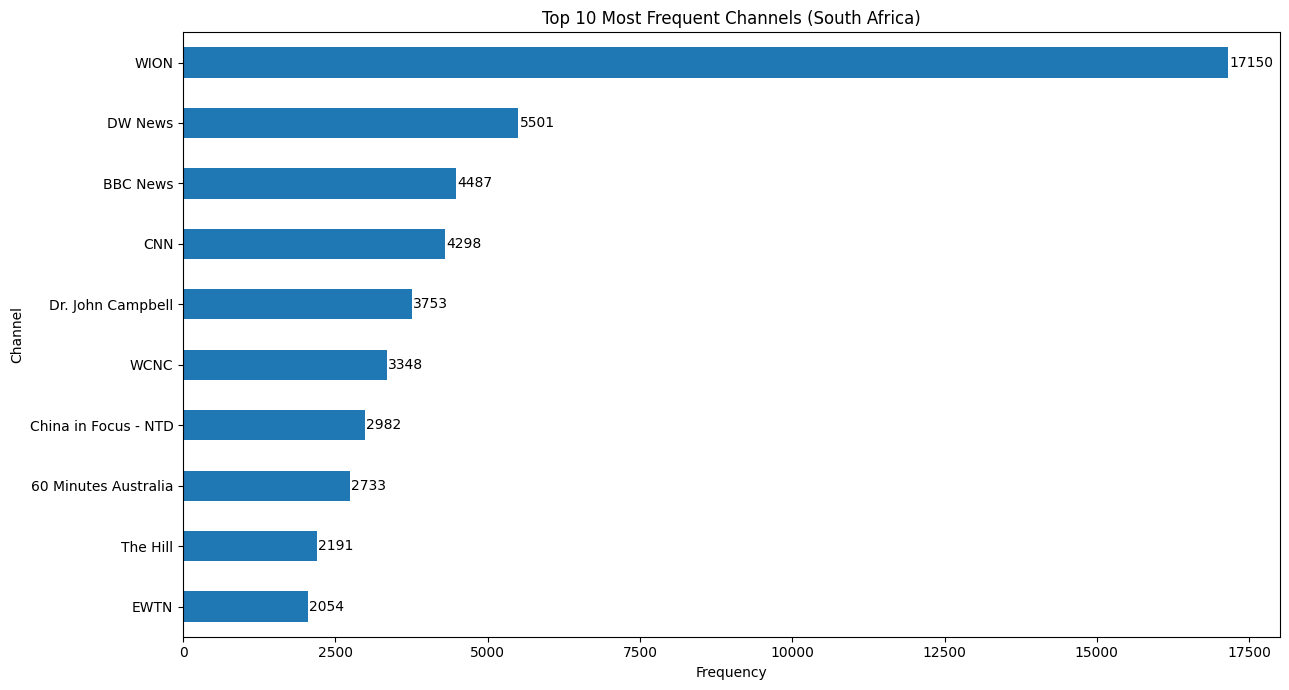

In [105]:
# top 10 most frequent channels per country
for country in youtube_search_result_df["country"].dropna().unique():
    # collect the data from one country at a time
    country_df = youtube_search_result_df[youtube_search_result_df["country"] == country]
    
    # get top 10 channels
    top_10_channels = country_df["Channel Name"].value_counts().head(10)
    # display(top_10_channels)
    
    # create a plot for each of the countries
    plt.figure(figsize=(13, 7))
    top_10_channels.sort_values().plot(kind="barh")
    plt.xlabel("Frequency")
    plt.ylabel("Channel")
    plt.title(f"Top 10 Most Frequent Channels ({country})")
    plt.tight_layout()
    # add values to bars
    for i, v in enumerate(top_10_channels.sort_values().values):
        plt.text(v + 20, i, v, va='center')
    plt.show()

The results from EDA 3 show that the top channels do differ between countries. The order of channels within the top 10 most frequent channels varies for each country, which suggests that users are being exposed to different sources depending on location.

This matters because repeated exposure to certain channels can shape the type of information users are being exposed to. If different channels are more frequent in each country, this may be responsible for some of the differences in misinformation levels seen in EDA 1 and EDA 2.

## EDA 4: Top 10 Channel Misinformation Rates

Next, to take a deeper look at the top channels in each country, I calculated the misinformation rate for the top 10 most frequent channels. This helps show whether repeated exposure to certain channels also corresponds to higher misinformation exposure.

This is important because combining channel frequency with misinformation rate gives a clearer picture of how reliable each channel’s content is.

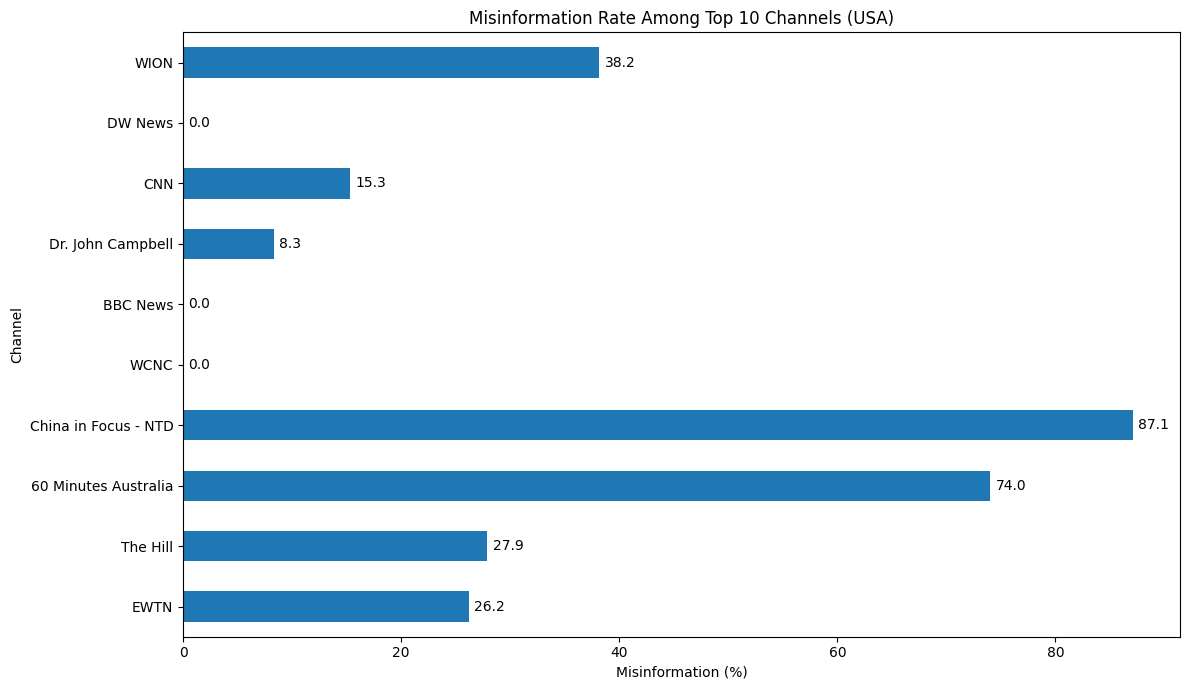

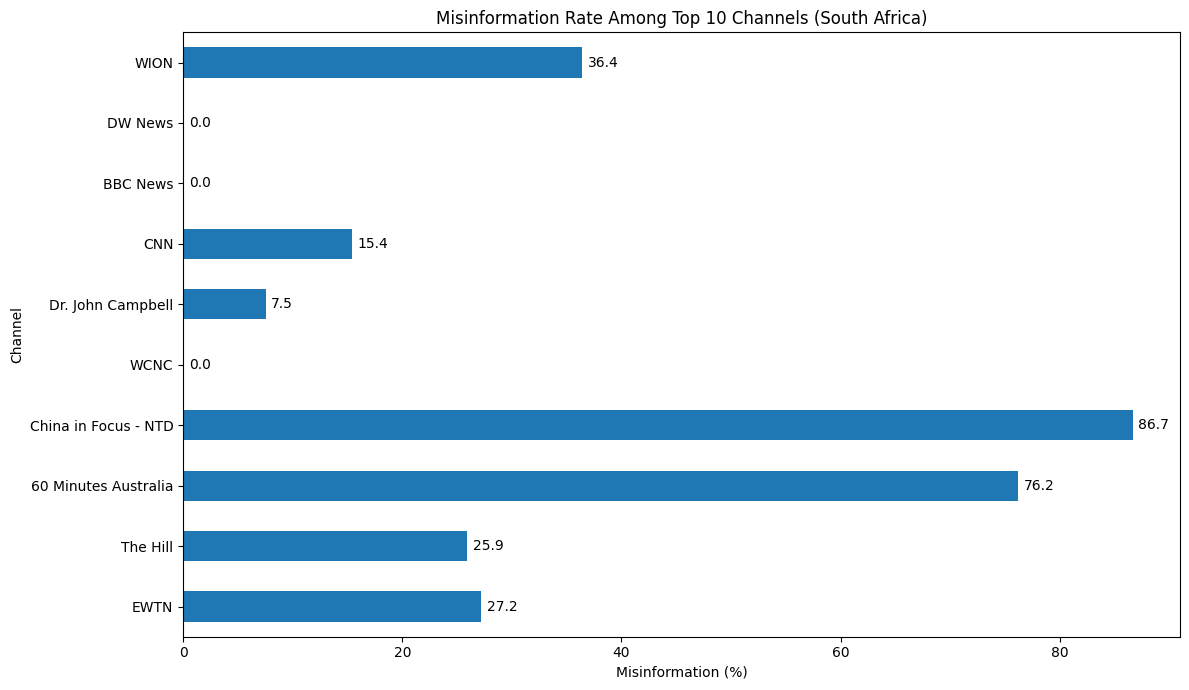

In [106]:
# misinformation rate for top 10 channels per country

youtube_search_result_df["annotation"] = pd.to_numeric(youtube_search_result_df["annotation"], errors="coerce")

# similar to EDA 3
# but add the additional layer of misinformation rate
for country in youtube_search_result_df["country"].dropna().unique():
    # filter to one country
    country_df = youtube_search_result_df[youtube_search_result_df["country"] == country]
    
    # get top 10 channels in that country
    top_10_channel_names = country_df["Channel Name"].value_counts().head(10).index
    
    # only keep rows from those top 10 channels
    top_channels_df = country_df[country_df["Channel Name"].isin(top_10_channel_names)]
    
    # calculate misinformation rate
    misinformation_counts = top_channels_df[top_channels_df["annotation"] == 1].groupby("Channel Name").size()
    total_counts = top_channels_df.groupby("Channel Name").size()

    channel_misinformation = (misinformation_counts / total_counts * 100).fillna(0)
    
    # keep same order as frequency plot
    channel_misinformation = channel_misinformation.loc[top_10_channel_names]
    #display(channel_misinformation)
    
    # plot
    plt.figure(figsize=(12, 7))
    channel_misinformation[::-1].plot(kind="barh")
    plt.xlabel("Misinformation (%)")
    plt.ylabel("Channel")
    plt.title(f"Misinformation Rate Among Top 10 Channels ({country})")
    plt.tight_layout()
    # add values to bars
    for i, v in enumerate(channel_misinformation[::-1].values):
        plt.text(v + 0.5, i, round(v, 1), va='center')
    plt.show()

The results from EDA 4 show that the misinformation rates of the top channels vary quite a bit. Some of the most frequently appearing channels have very low misinformation rates, such as BBC News, DW News, and WCNC. On the other hand, some frequent channels have much higher misinformation rates, including 60 Minutes Australia and China in Focus - NTD. This suggests that frequency alone does not fully explain misinformation exposure; some channels will appear often but be unreliable, and some channels may contribute a much higher proportion of misinformation than others. How often a channel appears and the type of content it produces are important in understanding what users are exposed to.

## EDA 5: Consistency Across Audit Runs

Lastly, I looked at how misinformation levels change across different audit runs. Since the same queries were repeated multiple times, this helps show whether the patterns seen earlier are consistent or just random. If misinformation levels stay similar across runs, it suggests that the results are stable and not caused by chance.

(0.0, 1.0)

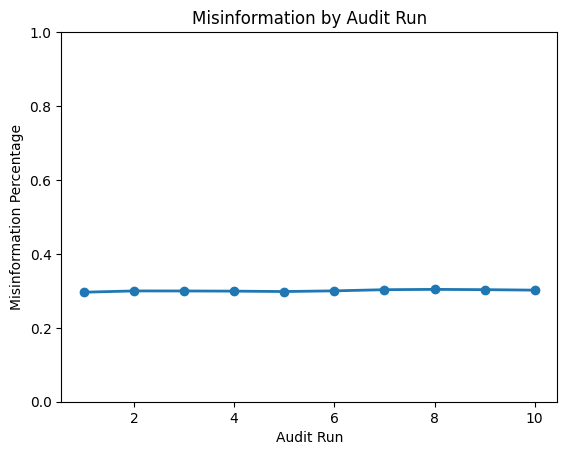

In [107]:
# EDA --> misinformation by audit run
misinformation_by_run = misinformation["Run #"].value_counts()
video_counts_run = youtube_search_result_df["Run #"].value_counts()

# final misinformation counts
run_misinformation = (misinformation_by_run/video_counts_run).fillna(0)
#print("Percent of Videos Leading Towards Misinformation Per Audit:")
#print(run_misinformation)

# barchart
run_misinformation.plot(marker="o", linewidth=2)
plt.title("Misinformation by Audit Run")
plt.ylabel("Misinformation Percentage")
plt.xlabel("Audit Run")
plt.ylim(0, 1)

The resulting figure from EDA 5 shows the percentage of videos labeled as supporting misinformation for each run. Looking at the results, the rate of misinformation remains relatively stable across all audit runs, staying around 0.29 to 0.30 with only small changes. This suggests that the patterns observed in earlier EDAs are stable over time. The differences in misinformation exposure are not random, but instead reflect consistent behavior in the search results.

These results support the use of sequential pattern mining in my project, since it allows me to analyze how content varies across audit runs, even when the overall misinformation rate does not change significantly.

---
## Frequent Itemset Mining

After exploring the data through EDA, I moved on to more advanced methods to better understand patterns in the search results.

While the EDA helped show overall trends, it does not capture how the channels appear together. To explore this further, I used frequent itemset mining to identify groups of channels that commonly appear together in search results.

For frequent itemset mining, I treated each country, query, and run combination as one transaction. Each channel is treated as an item in that transaction. This was essential for my research question because the transactions preserve geographic location while still allowing me to find channels that commonly appear together.

In [108]:
# Based on HW2: apriori of binary dataframe format
# Frequent channel patterns by country
# Had something similar in checkpoint 2, but updated it to connect country with the channels for final deliverable 
# group together by (country, Search Query, Run #) so it answers my research question better

import pandas as pd

# create a binary dataframe using the top 20 most frequent channels
top_20_channels = youtube_search_result_df["Channel Name"].value_counts().head(20).index

youtube_search_result_df_filtered = youtube_search_result_df[youtube_search_result_df["Channel Name"].isin(top_20_channels)][["country", "Search Query", "Run #", "Channel Name"]].dropna().drop_duplicates()
youtube_search_result_df_filtered["included"] = 1

youtube_search_result_df_filtered["transaction_id"] = (
    youtube_search_result_df_filtered["country"].astype(str) + " | " +
    youtube_search_result_df_filtered["Search Query"].astype(str) + " | Run " +
    youtube_search_result_df_filtered["Run #"].astype(str)
)

df_binary = youtube_search_result_df_filtered.pivot(
    index="transaction_id",
    columns="Channel Name",
    values="included"
).fillna(0).astype(int)
df_binary.index.name = "transaction_id"

print("Binary Dataframe shape:", df_binary.shape)
display(df_binary.head())

# print items in each transaction
for indx in df_binary.index[:1]:
    purchased = list(df_binary.columns[df_binary.loc[indx] == 1])
    print("transaction_id: ", indx, ", items: ", purchased, sep="")

Binary Dataframe shape: (945, 20)


Channel Name,60 Minutes Australia,BBC News,CGTN,CNN,Channels Television,China in Focus - NTD,DW News,Dr. John Campbell,EWTN,FRANCE 24 English,Global News,India Today,NTD,PBS NewsHour,Sky News,Sky News Australia,Spotlight on China,The Hill,WCNC,WION
transaction_id,,,,,,,,,,,,,,,,,,,,
South Africa | 5g_and_covid19_link | Run 1,1,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1
South Africa | 5g_and_covid19_link | Run 10,1,0,0,1,1,0,0,1,0,0,1,1,0,0,0,1,0,0,0,1
South Africa | 5g_and_covid19_link | Run 2,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1
South Africa | 5g_and_covid19_link | Run 3,1,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1
South Africa | 5g_and_covid19_link | Run 4,1,0,0,1,1,0,0,1,0,0,1,1,0,0,0,1,0,0,0,1


transaction_id: South Africa | 5g_and_covid19_link | Run 1, items: ['60 Minutes Australia', 'CNN', 'Channels Television', 'Dr. John Campbell', 'Global News', 'Sky News Australia', 'WION']


Next, I used an Apriori-style frequent itemset approach. I used minimum support to filter out rare channel pairs and minimum confidence to keep stronger association rules.

**Goal: find channels that frequently appear together in the same search result transactions**

In [113]:
def apriori_binary_format(data: pd.DataFrame, debug: bool, minsup: float, minconf: float):
    if(debug == True):
        print("Separate transactions within the data")

    transactions_dict = {}
    for indx, row in data.iterrows():
        # add each transation to dictionary
        purchased = list(data.columns[row == 1])
        transactions_dict[indx] = purchased

    # itemset calculations
    # pass 1: Read baskets (transactions) and count in main memory the occurrences of each individual item
    if(debug == True):
        print("Pass 1: Read baskets (transactions) and count in main memory the occurrences of each individual item")

    # count the occurrences of each individual item
    item_occurrences = {}
    for item in transactions_dict.values():
        for indiv in item:
            if indiv in item_occurrences:
                item_occurrences[indiv] += 1
            else:
                item_occurrences[indiv] = 1

    if(debug == True):
        print("Determining frequent items. Pass 1 minsup comparison")
    frequent_items = []
    items_pruned = []
    for item in item_occurrences.keys():
        if(item_occurrences[item] >= minsup):
            frequent_items.append(item)
        else: 
            items_pruned.append(item)
    if(debug == True):
        print("Frequent items: ", frequent_items, ", minsup: ", minsup, sep="")
        print("Pruned items: ", items_pruned,  ", minsup: ", minsup, sep="")

    # pass 2: Read baskets again and count in main memory only those pairs where both elements are frequent (from Pass 1)
    if(debug == True):
        print("Pass 2: Read baskets (transactions) again and count in main memory only those pairs where both elements are frequent (from Pass 1)")

    # count the occurrences of frequent pairs
    from itertools import combinations
    pair_occurrences = {}
    pair_combinations = list(combinations(frequent_items, 2))
    for item in transactions_dict.values():
        for pair in pair_combinations:
            if((pair[0] in item) and (pair[1] in item)):
                if pair in pair_occurrences:
                    pair_occurrences[pair] += 1
                else:
                    pair_occurrences[pair] = 1

    if(debug == True):
        print("Determining frequent pairs. Pass 2 minsup comparison")
    frequent_pairs = []
    pairs_pruned = []
    for pair in pair_occurrences.keys():
        if(pair_occurrences[pair] >= minsup):
            frequent_pairs.append(pair)
        else:
            pairs_pruned.append(pair)
    if(debug == True):
        print("Frequent pairs: ", frequent_pairs, ", minsup: ", minsup, sep="")
        print("Pruned pairs: ", pairs_pruned,  ", minsup: ", minsup, sep="")

    # outputs the association rules
    if(debug == True):
        print("Generating association rules and checking minconf")

    rules_keep = []
    rules_pruned = []
    for pair in frequent_pairs:
        pair_conf_1 = pair_occurrences[pair] / item_occurrences[pair[0]]
        if pair_conf_1 >= minconf:
            rules_keep.append([pair[0], "->", pair[1], pair_conf_1])
        else:
            rules_pruned.append([pair[0], "->", pair[1], pair_conf_1])

        pair_conf_2 = pair_occurrences[pair] / item_occurrences[pair[1]]
        if pair_conf_2 >= minconf:
            rules_keep.append([pair[1], "->", pair[0], pair_conf_2])
        else:
            rules_pruned.append([pair[1], "->", pair[0], pair_conf_2])
    if(debug == True):
        print("Valid Association Rules: ", rules_keep, ", minconf: ", minconf, sep="")
        print("Pruned Association Rules: ", rules_pruned,  ", minconf: ", minconf, sep="")

    return rules_keep

# frequent pair rules across all country-query-run pages
assoc_rules_binary = apriori_binary_format(df_binary, debug=False, minsup=5, minconf=0.6)
print("Top overall association rules from transactions:")
print(assoc_rules_binary[:20])

# compare rules by country
country_rule_summary = {}

for country_name in sorted(youtube_search_result_df_filtered["country"].unique()):
    country_transactions = youtube_search_result_df_filtered[youtube_search_result_df_filtered["country"] == country_name][["transaction_id", "Channel Name", "included"]]
    country_df_binary = country_transactions.pivot(index="transaction_id",columns="Channel Name",values="included").fillna(0).astype(int)
    country_rules = apriori_binary_format(country_df_binary, debug=False, minsup=3, minconf=0.6)
    country_rule_summary[country_name] = country_rules[:15]

for country_name, rules in country_rule_summary.items():
    print("\n", "Country: ", country_name, sep="")
    print("Rules:")
    for rule in rules[:10]:
        print(rule)

Top overall association rules from transactions:
[['60 Minutes Australia', '->', 'CNN', 0.7649667405764967], ['CNN', '->', '60 Minutes Australia', 0.6353591160220995], ['Dr. John Campbell', '->', '60 Minutes Australia', 0.7011834319526628], ['Sky News Australia', '->', '60 Minutes Australia', 0.7874396135265701], ['60 Minutes Australia', '->', 'WION', 0.7782705099778271], ['WION', '->', '60 Minutes Australia', 0.6136363636363636], ['Dr. John Campbell', '->', 'CNN', 0.7100591715976331], ['Global News', '->', 'CNN', 0.6617647058823529], ['Sky News Australia', '->', 'CNN', 0.6956521739130435], ['CNN', '->', 'WION', 0.7219152854511971], ['WION', '->', 'CNN', 0.6853146853146853], ['Channels Television', '->', 'Global News', 0.6601941747572816], ['Sky News Australia', '->', 'Dr. John Campbell', 0.6473429951690821], ['Dr. John Campbell', '->', 'WION', 0.8313609467455622], ['Global News', '->', 'WION', 0.6397058823529411], ['Sky News Australia', '->', 'WION', 0.961352657004831], ['India Today'

The frequent itemset results show which channels commonly appear together within each country’s search results. This helps move beyond individual channel frequency and shows repeated source groupings. Since the rules are generated separately by country, they help compare whether users in different locations are exposed to similar or different combinations of channels.

These patterns are important because users are not just seeing one channel at a time, but multiple channels together within a single search result page. If certain channels consistently appear together, they may reinforce similar types of content or viewpoints. The results from the frequent itemset mining provide more evidence that geographic location can influence which channels appear and how those channels are grouped together within search results.

Looking at the association rules, several channels consistently appear together within the same search results. For example, channels like 60 Minutes Australia, CNN, and WION frequently appear together, with relatively high confidence values. Rules such as “Sky News Australia → WION” (0.96) and “Dr. John Campbell → WION” (0.83) show that when one of these channels appears, the other is very likely to appear as well.

This is important because it shows that users are being exposed to groups of channels that tend to appear together. These groups of channels may have similar types of content, since users are likely to see multiple related sources within the same search results.

When comparing across countries, many of the same channel pairings appear in both the USA and South Africa, but with different confidence levels. For example, the rule “60 Minutes Australia → CNN” is stronger in the USA than in South Africa, suggesting that these channels are more tightly grouped in the USA. search results. This indicates that geographic location can influence not just which channels appear, but how strongly they are connected within search results.

These patterns suggest that differences in channel groupings may contribute to the variation in misinformation exposure observed earlier, since users in different locations are being exposed to slightly different combinations of channel sources.

---
## Sequence Pattern Mining
Next, to analyze how channels appear across different audit runs, I used sequence pattern mining (PrefixSpan). While frequent itemset mining shows which channels appear together, sequence mining helps capture patterns over time.

Since the same queries were repeated across multiple runs, this allowed for me to see whether certain channels consistently appear in similar positions across runs. To keep the results interpretable, I limited the analysis to the top 20 most frequent channels. This helped narrow it down and focus on meaningful patterns, rather than channels that are rarely seen in search results.

In [115]:
# use PrefixSpan for sequence pattern mining by country
from prefixspan import PrefixSpan

# sort data by run number
youtube_search_result_df_sorted = youtube_search_result_df.sort_values("Run #")

# loop through each country
for country in youtube_search_result_df_sorted["country"].dropna().unique():
    print("\n", "Country: ", country, sep="")
    
    # isolate data from one country at a time
    country_df = youtube_search_result_df_sorted[youtube_search_result_df_sorted["country"] == country]
    
    # get top 20 channels in that country
    top_20_channels = country_df["Channel Name"].value_counts().head(20).index
    
    # only keep top 20 channels
    country_df_filtered = country_df[country_df["Channel Name"].isin(top_20_channels)]
    
    # build sequences by search query
    sequence_data = country_df_filtered.groupby("Search Query")["Channel Name"].apply(list)
    sequences = sequence_data.tolist()
    
    # remove repeated channels within each sequence
    sequences = [list(dict.fromkeys(seq)) for seq in sequences]
    #print("Number of sequences:", len(sequences))
    
    # run PrefixSpan
    ps = PrefixSpan(sequences)
    patterns = ps.frequent(2)
    
    # sort patterns by support, highest first
    patterns = sorted(patterns, key=lambda x: x[0], reverse=True)
    
    # print top patterns
    print("Top 10 sequence patterns:")
    for pattern in patterns[:10]:
        print(pattern)


Country: USA
Top 10 sequence patterns:
(33, ['WION'])
(31, ['CNN'])
(26, ['60 Minutes Australia'])
(25, ['DW News'])
(24, ['CGTN'])
(23, ['PBS NewsHour'])
(22, ['Global News'])
(22, ['BBC News'])
(21, ['Dr. John Campbell'])
(20, ['WION', '60 Minutes Australia'])

Country: South Africa
Top 10 sequence patterns:
(34, ['WION'])
(29, ['CNN'])
(25, ['DW News'])
(23, ['Global News'])
(23, ['60 Minutes Australia'])
(22, ['BBC News'])
(21, ['PBS NewsHour'])
(20, ['Dr. John Campbell'])
(20, ['CGTN'])
(18, ['Sky News'])


The sequence pattern mining results show that many of the same channels appear repeatedly across audit runs in both countries. Channels like WION, CNN, DW News, and 60 Minutes Australia show up frequently in the top patterns for both the U.S. and South Africa. This suggests that search results are relatively stable over time, since the same channels continue to appear across multiple runs. This supports the findings from EDA 5, where misinformation levels remained consistent across runs.

There are also some small differences between countries. For example, Sky News appears in the top patterns for South Africa but not for the USA, which suggests that some channels are more prominent in certain locations. These differences further support the idea that geographic location can influence which channels that users are exposed to over time. 

The sequence patterns show that while search results are consistent across runs, there are still location-based differences in which channels appear most frequently. The appearance of repeated single-channel patterns also suggests that certain single channels are regularly showing within search results, meaning users may be consistently exposed to the same sources over time.

---
## Answer to Primary Research Question 
#### Does location affect YouTube search results and exposure to misinformation?

The results of this project show that geographic location does influence YouTube search results for the same query. Users in different countries are exposed to different channels, and these differences can lead to different levels of misinformation exposure. While search results are relatively consistent across runs, the specific channels and channel groupings vary by location. Geographic location does play an important role in determining how much misinformation users are being exposed to on YouTube.

---
## Limitations

The YouTube audit data and the methods that I used this analysis had some limitations:
- The dataset is limited to a relatively small number of search queries.
- The data was only collected over 10 audit days
- Focusing on a channel-level analysis was ideal for isolating overall patterns, but this could have missed important patterns between individual videos
- This dataset does not track user behavior. Within the data, I'm able to see what videos are shown to the users, but I'm not able to see which videos the users are actually watching.